# Front properties (groups)

In [17]:
# imports
from importlib import reload
import os

import numpy as np
import h5py
import xarray
import pandas

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import seaborn as sns

from skimage import morphology
import scipy.ndimage as ndi

from ocpy.utils import plotting 

from fronts.dbof import utils as dbof_utils
from fronts.dbof import io as dbof_io
from fronts.finding import dev as finding_dev
from fronts.finding import params as finding_params
from fronts.finding import pyboa as ff_pyboa
from fronts.finding import thin_cc
from fronts.finding import io as finding_io
from fronts.finding import cc_sst_preproc

# Load up group table

In [2]:
group_path = os.path.join(os.getenv('OS_OGCM'), 'LLC', 'Fronts' ,'group_fronts' ,'v1')

In [4]:
group_tbl_file = os.path.join(group_path, 'front_properties_20121109T12_00_00_v1_bin_A.parquet')

In [6]:
gtbl = pandas.read_parquet(group_tbl_file)
gtbl.head()

,flabel,npix,coriolis_f_mean,coriolis_f_std,coriolis_f_median,coriolis_f_p10,coriolis_f_p25,coriolis_f_p75,coriolis_f_p90,divergence_mean,...,V_p25,V_p75,V_p90,W_mean,W_std,W_median,W_p10,W_p25,W_p75,W_p90
0,1,13,-0.000143,1.884019e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,-5.427167e-06,...,-0.013987,0.009299,0.016614,7.924541e-07,9.985207e-08,7.693138e-07,6.842287e-07,7.159358e-07,8.615179e-07,9.433354e-07
1,2,20,-0.000143,2.018708e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,1.051717e-06,...,0.005101,0.016774,0.021964,8.096799e-07,1.318373e-07,8.290738e-07,5.839551e-07,7.413350e-07,9.165659e-07,9.565037e-07
2,3,28,-0.000143,2.317883e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,-3.063451e-06,...,-0.022933,0.007288,0.012676,6.156698e-07,5.224361e-07,6.213918e-07,3.224615e-07,5.065449e-07,8.346864e-07,1.086146e-06
3,4,128,-0.000143,4.652389e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,-3.053880e-06,...,-0.021386,0.005936,0.019350,1.090969e-06,2.234595e-07,1.138286e-06,8.068491e-07,9.786987e-07,1.241225e-06,1.315759e-06
4,5,27,-0.000143,2.268354e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,6.311122e-07,...,-0.011144,0.009972,0.019935,9.696325e-07,2.713012e-07,9.236500e-07,8.131438e-07,8.650712e-07,1.065129e-06,1.260055e-06


In [21]:
len(gtbl)

135654

In [8]:
np.array(gtbl.keys())

array(['flabel', 'npix', 'coriolis_f_mean', 'coriolis_f_std',
       'coriolis_f_median', 'coriolis_f_p10', 'coriolis_f_p25',
       'coriolis_f_p75', 'coriolis_f_p90', 'divergence_mean',
       'divergence_std', 'divergence_median', 'divergence_p10',
       'divergence_p25', 'divergence_p75', 'divergence_p90', 'Eta_mean',
       'Eta_std', 'Eta_median', 'Eta_p10', 'Eta_p25', 'Eta_p75',
       'Eta_p90', 'frontogenesis_tendency_mean',
       'frontogenesis_tendency_std', 'frontogenesis_tendency_median',
       'frontogenesis_tendency_p10', 'frontogenesis_tendency_p25',
       'frontogenesis_tendency_p75', 'frontogenesis_tendency_p90',
       'gradb2_mean', 'gradb2_std', 'gradb2_median', 'gradb2_p10',
       'gradb2_p25', 'gradb2_p75', 'gradb2_p90', 'gradeta2_mean',
       'gradeta2_std', 'gradeta2_median', 'gradeta2_p10', 'gradeta2_p25',
       'gradeta2_p75', 'gradeta2_p90', 'gradrho2_mean', 'gradrho2_std',
       'gradrho2_median', 'gradrho2_p10', 'gradrho2_p25', 'gradrho2_p75',
    

# CDFs

## Area vs. $|\nabla b|^2$

In [14]:
srt_gb = np.argsort(gtbl.gradb2_median)
#
area_gb_cdf = np.cumsum(gtbl.npix.values[srt_gb])
area_gb_cdf = area_gb_cdf / float(area_gb_cdf[-1])
area_gb_cdf

array([3.14945999e-06, 6.29891997e-06, 8.39855996e-06, ...,
       9.99974279e-01, 9.99976642e-01, 1.00000000e+00], shape=(135654,))

### Plot

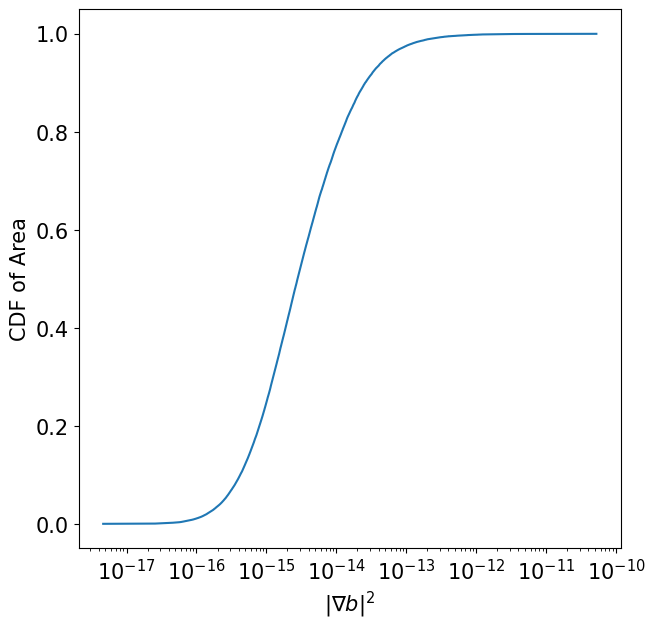

In [20]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(gtbl.gradb2_median[srt_gb], area_gb_cdf)
#
ax.set_xscale('log')
ax.set_xlabel(r'$|\nabla b|^2$')
ax.set_ylabel('CDF of Area')
#
plotting.set_fontsize(ax, 15.)
plt.show()

# Joint PDFs

## $\sigma/f$ vs. $|\nabla b|^2$

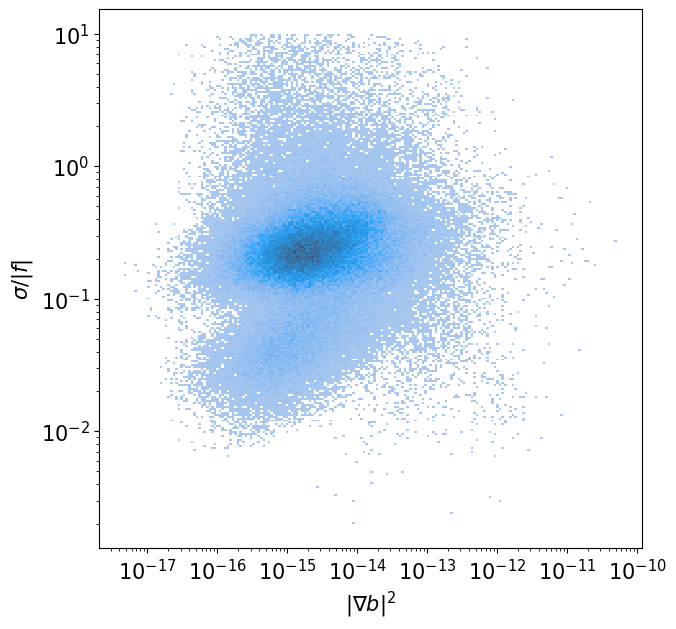

In [36]:
strain = gtbl.strain_mag_median/np.abs(gtbl.coriolis_f_median)
cut = (strain < 10.) & (strain > 1e-3)

#
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
sns.histplot(x=gtbl.gradb2_median[cut],y=strain[cut],
             log_scale=(True,True), ax=ax)
ax.set_xlabel(r'$|\nabla b|^2$')
ax.set_ylabel(r'$\sigma / |f|$')
plotting.set_fontsize(ax, 15.)
#
plt.show()

## $\delta$ vs. $|\nabla b|^2$

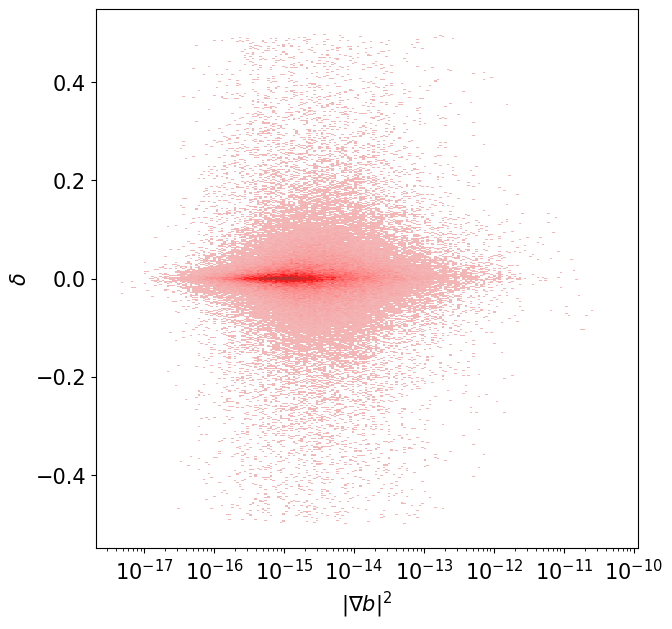

In [44]:
diverge = gtbl.divergence_median/np.abs(gtbl.coriolis_f_median)
cut = (diverge < 0.5) & (diverge > -0.5)

#
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
sns.histplot(x=gtbl.gradb2_median[cut], y=diverge[cut],
             log_scale=(True,False), ax=ax, color='red')
ax.set_xlabel(r'$|\nabla b|^2$')
ax.set_ylabel(r'$\delta$')
plotting.set_fontsize(ax, 15.)
#
plt.show()

In [ ]:
## 